# GCC on Facebook

This notebook explores the **global clustering coefficient (GCC)** on the Facebook ground-truth graph. The goal is tactile understanding: we compute the metric on the full graph, then inspect a smaller subgraph and manually verify how wedges and triangles enter the formula.

## Metric definition

For a graph $G$, let

$$n_w(G)=
\sum_{v\in V} \binom{d(v)}{2}$$

be the number of wedges, and let $\Delta(G)$ be the number of **unique** triangles. Then

$$\mathrm{GCC}(G)=\frac{\Delta(G)}{n_w(G)}.$$

Interpretation: among all places where a triangle could happen, how often does it happen?

In [2]:

from pathlib import Path
import sys

import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NOTEBOOK_DIR = Path.cwd()
if not (NOTEBOOK_DIR / 'metrics.py').exists():
    NOTEBOOK_DIR = NOTEBOOK_DIR.parent

sys.path.insert(0, str(NOTEBOOK_DIR))
from metrics import (
    load_graph,
    unique_triangle_count,
    wedge_count,
    gcc,
)

DATA_PATH = NOTEBOOK_DIR.parent / 'data' / 'gt_txt' / 'facebook.txt'
G = load_graph(DATA_PATH)
print(f'Loaded {DATA_PATH.name}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')


Loading graph: 88234it [00:00, 686982.50it/s]


Loaded facebook.txt: 4039 nodes, 88234 edges


In [3]:

def induced_ego_subgraph(G, center=None, radius=1, max_nodes=40):
    if center is None:
        center = max(G.degree, key=lambda x: x[1])[0] # center on node with most neighbors
    nodes = set(nx.single_source_shortest_path_length(G, center, cutoff=radius).keys()) # all nodes within radius of center
    H = G.subgraph(nodes).copy() # don't modify G
    if H.number_of_nodes() > max_nodes: # if too many nodes, keep only those with highest degree
        nbrs = sorted(H.nodes(), key=lambda u: (-G.degree[u], u))[:max_nodes]
        H = G.subgraph(nbrs).copy()
    return center, H

# Get the edge list of a graph
def edge_df(G):
    return pd.DataFrame(sorted((min(u,v), max(u,v)) for u,v in G.edges()), columns=['u','v'])


In [4]:
triangles = unique_triangle_count(G)
wedges = wedge_count(G)
gcc_value = gcc(G)

pd.set_option('display.float_format', '{:.4f}'.format)

pd.DataFrame([
    {'metric': 'unique triangles', 'value': triangles},
    {'metric': 'wedges', 'value': wedges},
    {'metric': 'GCC', 'value': gcc_value},
])

,metric,value
0,unique triangles,1612010.0000
1,wedges,9314849.0000
2,GCC,0.5192


## A small example

We take a 1-hop ego-style induced subgraph around a high-degree node so that wedges and triangles are small enough to inspect.

In [5]:
center, H = induced_ego_subgraph(G, radius=1, max_nodes=25)
print('center node:', center)
print('subgraph nodes:', H.number_of_nodes(), 'edges:', H.number_of_edges())
edge_df(H).head(20)

center node: 80
subgraph nodes: 25 edges: 213


,u,v
0,0,80
1,80,81
2,80,86
3,80,111
4,80,122
5,80,168
6,80,242
7,80,260
8,80,284
9,80,319


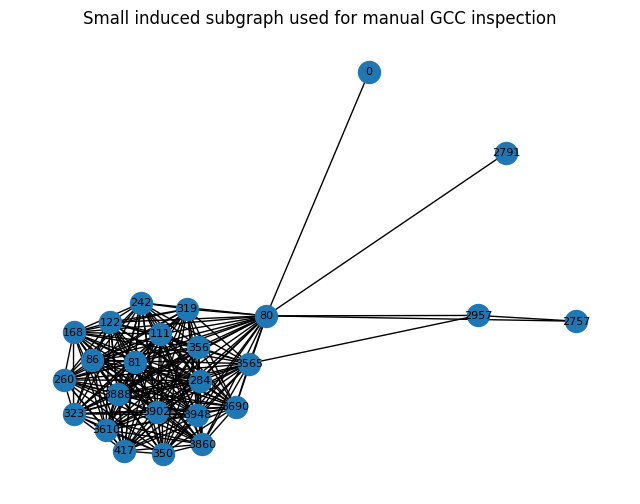

In [6]:
pos = nx.spring_layout(H, seed=7)
plt.figure(figsize=(8,6))
nx.draw_networkx(H, pos=pos, node_size=250, font_size=8)
plt.title('Small induced subgraph used for manual GCC inspection')
plt.axis('off')
plt.show()

In [8]:
triangles_H = unique_triangle_count(H)
wedges_H = wedge_count(H)
gcc_H = gcc(H)
pd.DataFrame([
    {'metric': 'unique triangles', 'value': triangles_H},
    {'metric': 'wedges', 'value': wedges_H},
    {'metric': 'GCC', 'value': gcc_H},
])

,metric,value
0,unique triangles,1276.0000
1,wedges,3985.0000
2,GCC,0.9606


## Where do wedges come from?

For each node, $\binom{d(v)}{2}$ counts how many unordered pairs of neighbors it has. Each such pair gives a wedge centered at $v$.

In [9]:
import math

wedge_contrib = []
for u, d in H.degree():
    if d >= 2:
        wedge_contrib.append({'node': u, 'degree': d, 'wedge_contribution': math.comb(d, 2)})
pd.DataFrame(wedge_contrib).sort_values('wedge_contribution', ascending=False).head(15)

,node,degree,wedge_contribution
12,80,24,276
2,3860,20,190
0,260,20,190
5,417,20,190
4,284,20,190
6,168,20,190
3,3610,20,190
22,122,20,190
10,323,20,190
14,86,20,190


## Manual triangle listing on the small subgraph

NetworkX can list all cliques; filtering to size 3 gives all unique triangles.

In [10]:
tri_list = [tuple(sorted(c)) for c in nx.enumerate_all_cliques(H) if len(c) == 3]
pd.DataFrame({'triangle': tri_list}).head(20)

,triangle
0,"(260, 3610, 3860)"
1,"(260, 284, 3860)"
2,"(260, 417, 3860)"
3,"(168, 260, 3860)"
4,"(260, 3860, 3888)"
5,"(260, 3860, 3902)"
6,"(260, 319, 3860)"
7,"(260, 323, 3860)"
8,"(80, 260, 3860)"
9,"(81, 260, 3860)"


## Interpretation

- A **high GCC** means wedges frequently close into triangles.
- A **low GCC** means many open two-step patterns remain open.

For realism, a generated graph should have a similar GCC if it truly reproduces Facebook-like triangle closure.